<a href="https://colab.research.google.com/github/Boulder1-kihara/heart-disease-prediction/blob/main/Heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content/drive/MyDrive/heart disease prediction

/content/drive/MyDrive/heart disease prediction


In [2]:
import numpy as np
import pandas as pd
import shap
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier

In [3]:
# 1. Load Data
df = pd.read_csv("/content/drive/MyDrive/heart disease prediction/heart.csv")

# 2. Fix Clinical Gotchas & Invalid Zeros
# Serum cholesterol and resting BP cannot physiologically be 0
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)

X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

# 3. Categorize Feature Types
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
bin_cols = ["FastingBS"]  # Already binary (0/1)

In [4]:
# 4. Construct Preprocessing Pipelines
# KNN works well for imputing missing biological markers based on similar patient profiles
num_transformer = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", RobustScaler()),  # Outlier-resistant scaling
    ]
)

cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
        ("bin", "passthrough", bin_cols),
    ]
)

In [5]:
# 5. Model Definition
# scale_pos_weight balances recall if class distribution shifts slightly
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
)

clf_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", model)]
)

In [6]:
# 6. Stratified Cross-Validation (5-Fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_scores = []

print("Running 5-Fold Stratified Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    clf_pipeline.fit(X_train, y_train)
    y_pred_proba = clf_pipeline.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)
    cv_auc_scores.append(auc)
    print(f"  Fold {fold} ROC-AUC: {auc:.4f}")

print(
    f"\nMean ROC-AUC: {np.mean(cv_auc_scores):.4f} ± {np.std(cv_auc_scores):.4f}"
)

Running 5-Fold Stratified Cross-Validation...
  Fold 1 ROC-AUC: 0.9485
  Fold 2 ROC-AUC: 0.9303
  Fold 3 ROC-AUC: 0.8745
  Fold 4 ROC-AUC: 0.9344
  Fold 5 ROC-AUC: 0.9184

Mean ROC-AUC: 0.9212 ± 0.0253



Generating SHAP Summary Plot...


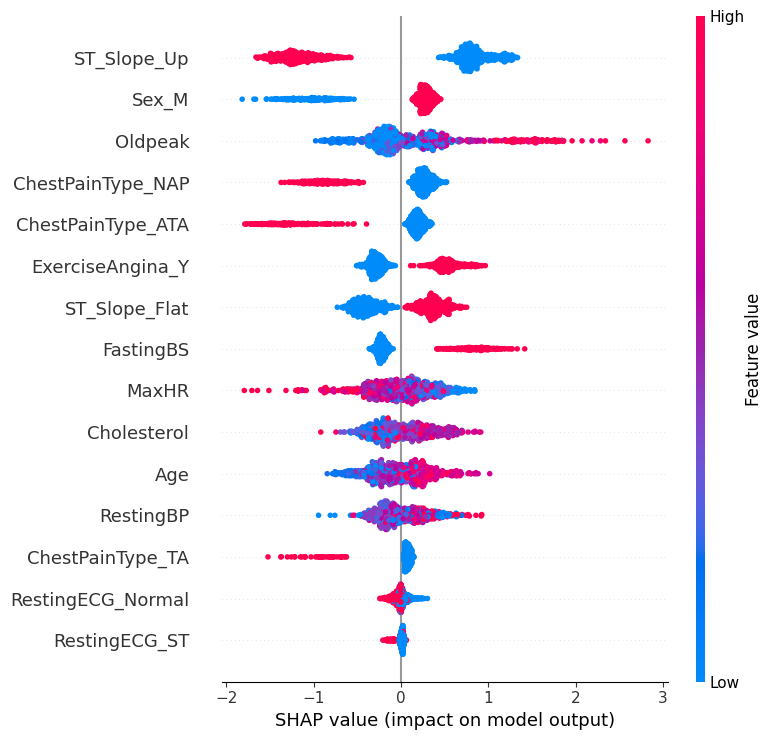

In [7]:
# 7. Model Explainability with SHAP (Full Dataset Fit)
clf_pipeline.fit(X, y)

# Extract transformed feature names
prepped_X = clf_pipeline.named_steps["preprocessor"].transform(X)
ohe_names = (
    clf_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(cat_cols)
    .tolist()
)
feature_names = num_cols + ohe_names + bin_cols

# Compute SHAP values
explainer = shap.TreeExplainer(clf_pipeline.named_steps["classifier"])
shap_values = explainer.shap_values(prepped_X)

print("\nGenerating SHAP Summary Plot...")
shap.summary_plot(shap_values, prepped_X, feature_names=feature_names)

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)
from sklearn.model_selection import cross_val_predict

In [9]:
# 1. Generate out-of-fold predicted probabilities using your existing clf_pipeline
# cross_val_predict ensures every probability is predicted on an unseen validation fold
y_probs = cross_val_predict(
    clf_pipeline, X, y, cv=skf, method="predict_proba"
)[:, 1]

# 2. Compute Precision-Recall curve values
precisions, recalls, thresholds = precision_recall_curve(y, y_probs)

# 3. Find the optimal threshold for Recall >= 0.95
target_recall = 0.95

# Find all indices where recall satisfies the >= 0.95 condition
valid_indices = np.where(recalls[:-1] >= target_recall)[0]

# Pick the threshold in that subset that maximizes precision
best_idx = valid_indices[np.argmax(precisions[valid_indices])]
optimal_threshold = thresholds[best_idx]
optimal_precision = precisions[best_idx]
achieved_recall = recalls[best_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f} 🎯")
print(f"Achieved Recall:   {achieved_recall:.4f}")
print(f"Precision:         {optimal_precision:.4f}\n")

Optimal Threshold: 0.2396 🎯
Achieved Recall:   0.9508
Precision:         0.8010



/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


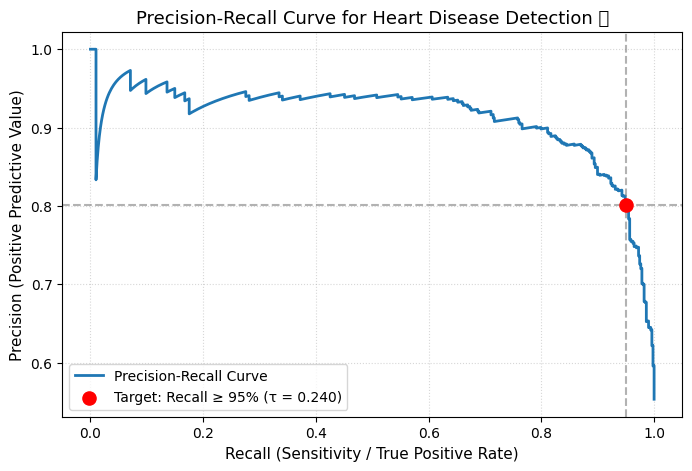

In [10]:
# 4. Plot Precision-Recall Curve with Selected Operating Point
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color="#1f77b4", lw=2, label="Precision-Recall Curve")
plt.scatter(
    achieved_recall,
    optimal_precision,
    color="red",
    s=90,
    zorder=5,
    label=f"Target: Recall ≥ {int(target_recall*100)}% (τ = {optimal_threshold:.3f})",
)

plt.axvline(
    x=achieved_recall, color="gray", linestyle="--", alpha=0.6
)
plt.axhline(
    y=optimal_precision, color="gray", linestyle="--", alpha=0.6
)

plt.title("Precision-Recall Curve for Heart Disease Detection 🫀", fontsize=13)
plt.xlabel("Recall (Sensitivity / True Positive Rate)", fontsize=11)
plt.ylabel("Precision (Positive Predictive Value)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="lower left")
plt.show()

In [11]:
# 5. Evaluate Clinical Performance Shift
y_pred_default = (y_probs >= 0.50).astype(int)
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

print("--- Default Threshold (0.50) ---")
print(classification_report(y, y_pred_default, digits=4))

print(f"--- Calibrated Threshold ({optimal_threshold:.4f}) ---")
print(classification_report(y, y_pred_optimal, digits=4))

--- Default Threshold (0.50) ---
              precision    recall  f1-score   support

           0     0.8568    0.8317    0.8441       410
           1     0.8673    0.8878    0.8774       508

    accuracy                         0.8627       918
   macro avg     0.8620    0.8598    0.8607       918
weighted avg     0.8626    0.8627    0.8625       918

--- Calibrated Threshold (0.2396) ---
              precision    recall  f1-score   support

           0     0.9206    0.7073    0.8000       410
           1     0.8010    0.9508    0.8695       508

    accuracy                         0.8420       918
   macro avg     0.8608    0.8291    0.8347       918
weighted avg     0.8544    0.8420    0.8385       918



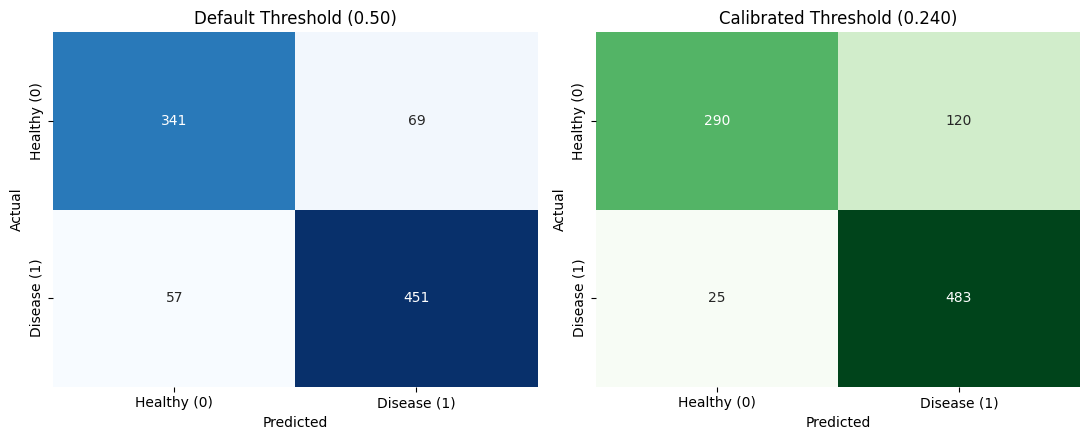

In [14]:
# 6. Visualize Confusion Matrix Comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_default = confusion_matrix(y, y_pred_default)
cm_optimal = confusion_matrix(y, y_pred_optimal)

sns.heatmap(
    cm_default,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
    xticklabels=["Healthy (0)", "Disease (1)"],
    yticklabels=["Healthy (0)", "Disease (1)"],
)
axes[0].set_title("Default Threshold (0.50)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_optimal,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    ax=axes[1],
    xticklabels=["Healthy (0)", "Disease (1)"],
    yticklabels=["Healthy (0)", "Disease (1)"],
)
axes[1].set_title(f"Calibrated Threshold ({optimal_threshold:.3f})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Total False Negatives under τ = 0.2396: 25

--- False Negative Case #1 (Index: 1, Predicted Risk: 0.152) ---
Age                49
Sex                 F
ChestPainType     NAP
MaxHR             156
Oldpeak           1.0
ST_Slope         Flat
Name: 1, dtype: object


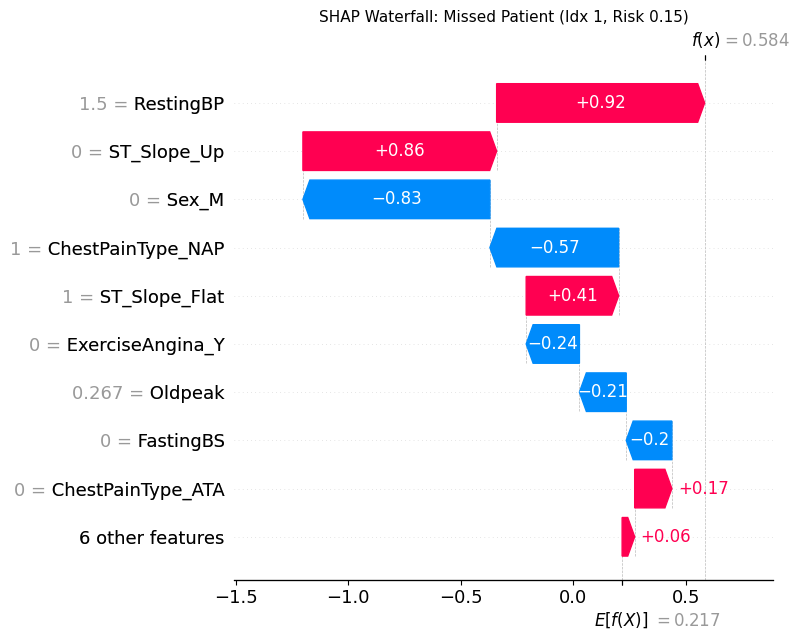


--- False Negative Case #2 (Index: 144, Predicted Risk: 0.091) ---
Age                56
Sex                 F
ChestPainType     ATA
MaxHR             150
Oldpeak           1.0
ST_Slope         Flat
Name: 144, dtype: object


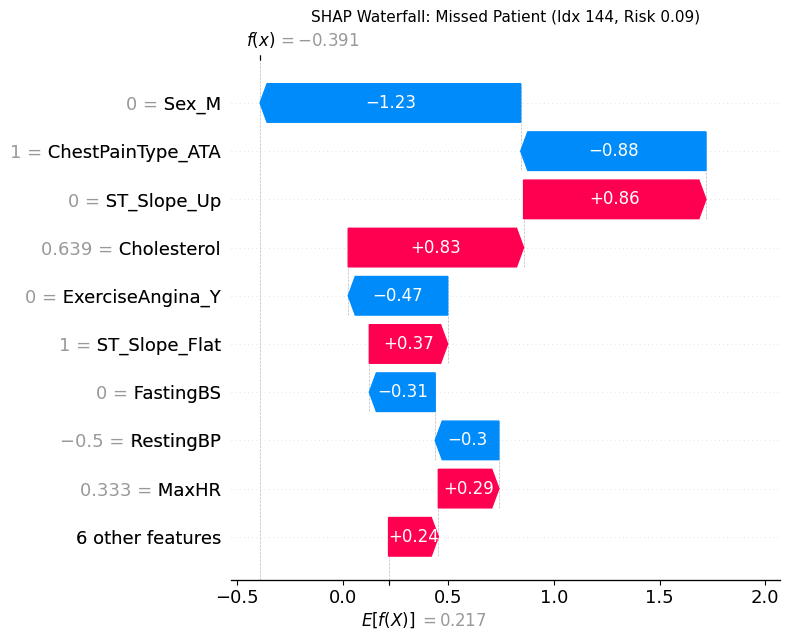

In [17]:
# Identify indices of False Negatives under the calibrated threshold
# Actual Disease (y == 1), but predicted Healthy (y_pred_optimal == 0)
fn_mask = (y.values == 1) & (y_pred_optimal == 0)
fn_indices = np.where(fn_mask)[0]

print(f"Total False Negatives under τ = {optimal_threshold:.4f}: {len(fn_indices)}")

# Generate an Explanation object compatible with shap.plots.waterfall
explanation = explainer(prepped_X)
explanation.feature_names = feature_names

# Plot the waterfall explanation for the first 2 false negative patients
for i, idx in enumerate(fn_indices[:2], 1):
    pred_prob = y_probs[idx]

    print(f"\n--- False Negative Case #{i} (Index: {idx}, Predicted Risk: {pred_prob:.3f}) ---")
    print(df.iloc[idx][['Age', 'Sex', 'ChestPainType', 'MaxHR', 'Oldpeak', 'ST_Slope']])

    plt.figure()
    shap.plots.waterfall(explanation[idx], max_display=10, show=False)
    plt.title(f"SHAP Waterfall: Missed Patient (Idx {idx}, Risk {pred_prob:.2f})", fontsize=11)
    plt.tight_layout()
    plt.show()